In [1]:
import pandas as pd
true = pd.read_csv("True.csv")
fake = pd.read_csv("Fake.csv")
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [20]:
print(df.shape)

(44898, 6)


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
 5   content  44898 non-null  str  
dtypes: int64(1), str(5)
memory usage: 222.3 MB


In [22]:
print(df.duplicated().sum())

209


In [23]:
df.drop_duplicates(inplace=True)

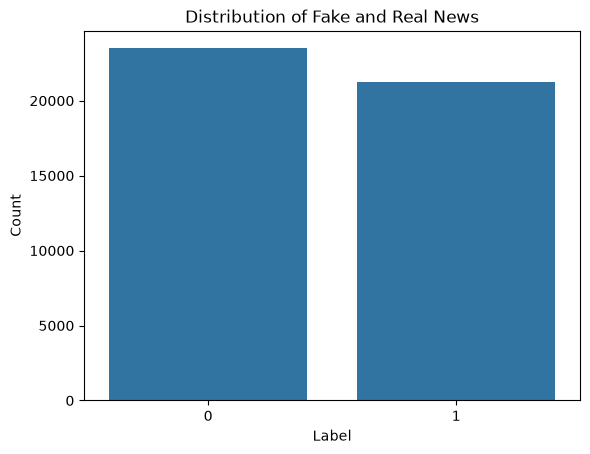

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='label', data=df)
plt.title("Distribution of Fake and Real News")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

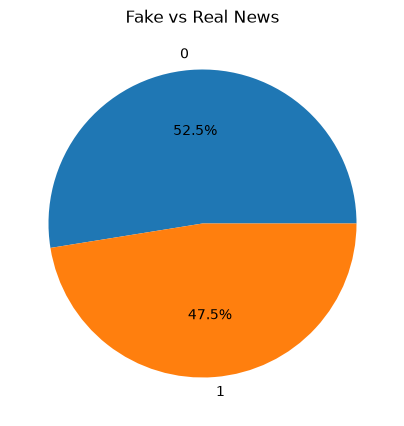

In [27]:
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5)
)

plt.ylabel("")
plt.title("Fake vs Real News")
plt.show()

In [28]:
df['subject'].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

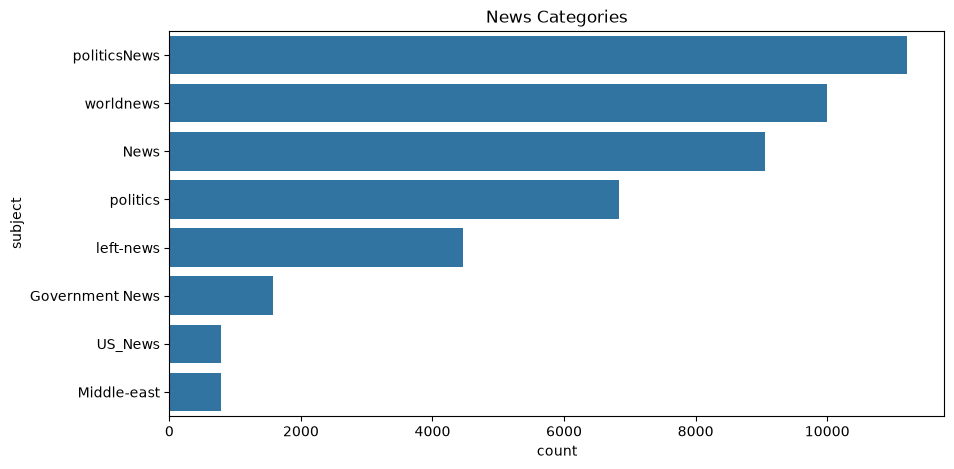

In [29]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='subject',
    data=df,
    order=df['subject'].value_counts().index
)

plt.title("News Categories")
plt.show()

In [30]:
df['text_length'] = df['text'].apply(len)

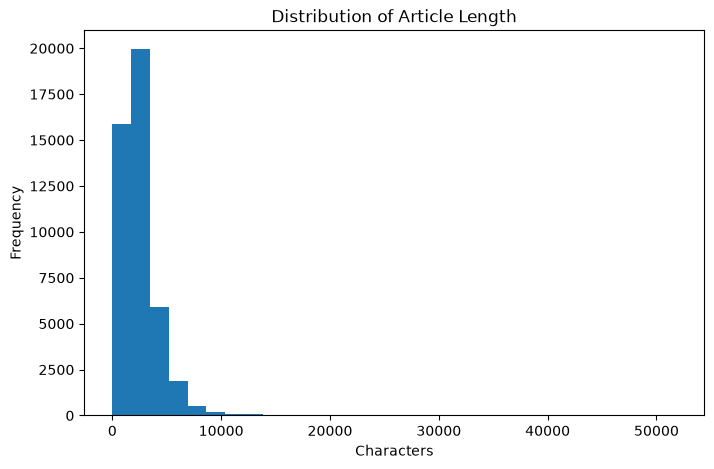

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df['text_length'], bins=30)

plt.title("Distribution of Article Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

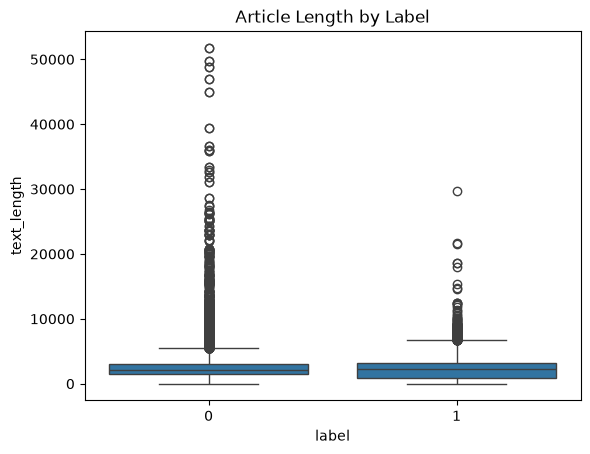

In [33]:
sns.boxplot(x='label', y='text_length', data=df)

plt.title("Article Length by Label")
plt.show()

In [34]:
df['title_length'] = df['title'].apply(len)

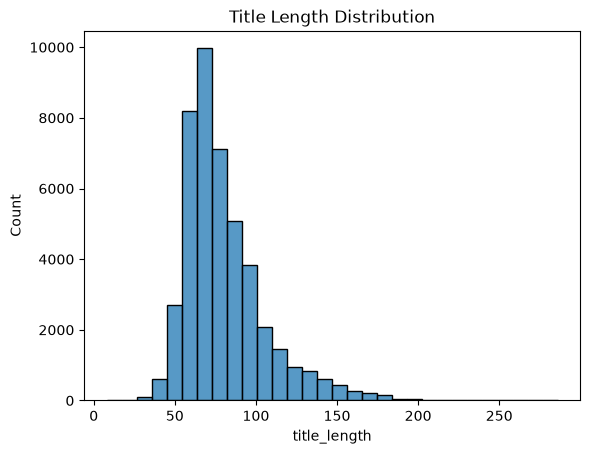

In [35]:
sns.histplot(df['title_length'], bins=30)
plt.title("Title Length Distribution")
plt.show()

In [36]:
numeric = df[['text_length','title_length']]

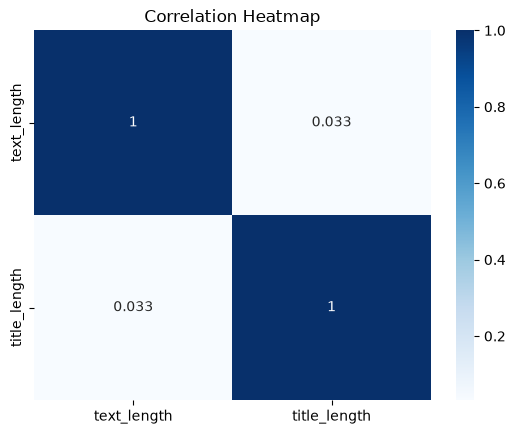

In [37]:
sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

In [38]:
true['label'] = 1
fake['label'] = 0

In [39]:
df = pd.concat([true, fake])
df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [40]:
df = df.sample(frac=1).reset_index(drop=True)

In [41]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [42]:
df['content'] = df['title'] + " " + df['text']

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000
)
X = vectorizer.fit_transform(df['content'])
y = df['label']

In [44]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6417602 stored elements and shape (35918, 5000)>

In [45]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)
lr_pred

array([1, 1, 1, ..., 0, 0, 1], shape=(8980,))

In [46]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:",
      accuracy_score(y_test,lr_pred))

Logistic Regression: 0.989086859688196
